# In case we'll lose other means of communications at some point, we can use this cell for chatting
Polina: hello

In [ ]:
!pip install transformers torch biopython requests numpy scipy

In [ ]:
!curl -sSL https://securedna.github.io/ppa/deb/securedna-keyring.gpg | sudo tee /usr/share/keyrings/securedna-keyring.gpg > /dev/null
!echo "deb [signed-by=/usr/share/keyrings/securedna-keyring.gpg] https://securedna.github.io/ppa/deb ./" | sudo tee /etc/apt/sources.list.d/securedna.list > /dev/null
!sudo apt update
!sudo apt install -y synthclient

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 https://securedna.github.io/ppa/deb ./ InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 2s (2,540 B/s)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
55 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem

In [ ]:
#PARAMETERS

#For Cell 6
TOXIN_DB_PATH = "embeddings/toxin_embeddings_large.npz"
MAX_TOXINS = 25000   # number of toxins to fetch (higher = more accurate, slower)

#For Cell 6.1
NEUTRAL_DB_PATH = "embeddings/neutral_embeddings_large.npz"
MAX_NEUTRALS = 25000   # number of neutrals to fetch (higher = more accurate, slower)

In [ ]:
# =============================================================================
# BIOSECURITY SCREENING PIPELINE — MVP
# Second-layer functional screening on top of SecureDNA
# =============================================================================

# ── Cell 1: imports ─────────────────────────────────────────────────────────

import os
import json
import time
import warnings
import numpy as np
import requests
from typing import Optional
from dataclasses import dataclass, field, asdict

warnings.filterwarnings("ignore")

# Biopython — DNA → protein translation
from Bio.Seq import Seq

# HuggingFace transformers — ESM2 embeddings
import torch
from transformers import AutoTokenizer, AutoModel

print("✓ Imports successful")

✓ Imports successful


In [ ]:
# =============================================================================
# ── Cell 2: data structures ───────────────────────────────────────────────────
# =============================================================================

@dataclass
class ScreeningResult:
    """Result of screening a single sequence."""

    # Input data
    dna_sequence: str
    protein_sequence: str = ""

    # Layer 1: SecureDNA
    securedna_flagged: Optional[bool] = None   # True = dangerous
    securedna_raw: dict = field(default_factory=dict)

    # Layer 2: functional (ESM2)
    functional_score: Optional[float] = None   # 0.0–1.0, higher = more dangerous
    S_toxin: Optional[float] = None
    S_bg: Optional[float] = None
    top_matches: list = field(default_factory=list)  # [(toxin_name, score), ...]

    # Final verdict
    combined_risk: str = "UNKNOWN"   # SAFE / SUSPICIOUS / DANGEROUS
    combined_score: Optional[float] = None

    def to_dict(self):
        return asdict(self)

In [ ]:
# =============================================================================
# ── Cell 3: DNA → protein translation ────────────────────────────────────────
# =============================================================================

def translate_dna(dna: str) -> str:
    """
    Translates a DNA sequence into an amino acid sequence.
    Tries all 3 reading frames, returns the longest ORF.
    Stop codons are marked as '*', they are truncated.
    """
    dna = dna.upper().strip()
    best = ""

    for frame in range(3):
        fragment = dna[frame:]
        # Trim to multiple of 3
        fragment = fragment[:len(fragment) - len(fragment) % 3]
        protein = str(Seq(fragment).translate())
        # Cut at first stop codon
        if "*" in protein:
            protein = protein[:protein.index("*")]
        if len(protein) > len(best):
            best = protein

    return best

# **BELOW WE HAVE A PLACEHOLDER FOR SecureDNA API call!!!!!!!!!!!!!!!!!**
**OUTPUTS ARE RANDOM!**

**TODO: replace with an actual solution once our registration is complete**

In [ ]:
# =============================================================================
# ── Cell 4: SecureDNA Real Integration (Layer 1) ────────────────────────────
# =============================================================================

import os
import subprocess
import tempfile
import json
import time
import shutil
from typing import Dict

# ================== CONFIG ==================
USE_SECUREDNA_STUB = False   # ← Change to False when ready

# ←←← UPDATE THESE PATHS WITH YOUR ACTUAL FILES ←←←
SECUREDNA_CERT_PATH = "/content/apart-research-leaf.manufacturer.cert"   # Upload your .certr file here
SECUREDNA_TOKEN_PATH = ""                                 # Usually not needed if using cert

# Check if synthclient is available
def synthclient_available() -> bool:
    return shutil.which("synthclient") is not None

print(f"synthclient available: {synthclient_available()}")
# ===========================================

def aa_to_dna(aa_seq: str) -> str:
    """Simple back-translation using common codons (good enough for screening)."""
    codon_table = {
        'A': 'GCT', 'C': 'TGT', 'D': 'GAT', 'E': 'GAA', 'F': 'TTT',
        'G': 'GGT', 'H': 'CAT', 'I': 'ATT', 'K': 'AAA', 'L': 'CTG',
        'M': 'ATG', 'N': 'AAT', 'P': 'CCT', 'Q': 'CAA', 'R': 'CGT',
        'S': 'TCT', 'T': 'ACT', 'V': 'GTT', 'W': 'TGG', 'Y': 'TAT',
        '*': 'TAA'
    }
    return ''.join(codon_table.get(aa.upper(), 'GCT') for aa in aa_seq.strip())


def screen_securedna_real(aa_sequence: str) -> Dict:
    """
    Full real SecureDNA call.
    Input: Amino acid sequence
    Output: dict with screening result + timing
    """
    start_time = time.time()

    try:
        dna = aa_to_dna(aa_sequence)

        # Create temporary FASTA
        with tempfile.NamedTemporaryFile(mode="w", suffix=".fasta", delete=False) as f:
            f.write(f">query_protein\n{dna}\n")
            fasta_path = f.name

        cmd = ["synthclient", "--fasta", fasta_path]

        if SECUREDNA_CERT_PATH and os.path.exists(SECUREDNA_CERT_PATH):
            cmd += ["--cert", SECUREDNA_CERT_PATH]

        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=120   # generous timeout
        )

        os.unlink(fasta_path)

        elapsed = time.time() - start_time

        if result.returncode != 0:
            return {
                "success": False,
                "flagged": None,
                "error": result.stderr.strip(),
                "runtime_seconds": round(elapsed, 3),
                "provider": "SecureDNA"
            }

        data = json.loads(result.stdout)
        flagged = any(r.get("hits") for r in data.get("results", []))

        return {
            "success": True,
            "flagged": flagged,
            "hits": data.get("results", []),
            "runtime_seconds": round(elapsed, 3),
            "dna_length": len(dna),
            "provider": "SecureDNA"
        }

    except Exception as e:
        elapsed = time.time() - start_time
        return {
            "success": False,
            "flagged": None,
            "error": str(e),
            "runtime_seconds": round(elapsed, 3),
            "provider": "SecureDNA (exception)"
        }


# Backward compatibility with existing code
def screen_layer1(dna_or_aa: str) -> Dict:
    """Accepts either DNA or AA sequence."""
    # If it looks like DNA, use directly; else assume AA and translate
    if all(c in "ATGCN" for c in dna_or_aa.upper()[:50]):
        return screen_securedna_real(dna_or_aa)   # already DNA? rare
    else:
        return screen_securedna_real(dna_or_aa)   # treat as AA

synthclient available: True


In [ ]:
# =============================================================================
# ── Cell 5: ESM2 embeddings (Layer 2, Part A) ────────────────────────────────
# =============================================================================
#
# ESM2 — protein language model from Meta.
# Model esm2_t6_8M_UR50D is the smallest (8M parameters), runs on CPU.
# If GPU is available → use esm2_t33_650M_UR50D (650M parameters, higher accuracy).
#
# Model sizes:
#   esm2_t6_8M_UR50D    — 8M parameters, ~31 MB,  CPU: ~1 sec/protein
#   esm2_t12_35M_UR50D  — 35M parameters, ~139 MB, CPU: ~3 sec/protein
#   esm2_t30_150M_UR50D — 150M parameters, ~591 MB, CPU: ~10 sec/protein  ← good balance
#   esm2_t33_650M_UR50D — 650M parameters, ~2.5 GB, GPU recommended
# =============================================================================

# Model selection — change if needed
#ESM2_MODEL_NAME = "facebook/esm2_t6_8M_UR50D"   # fast for testing
ESM2_MODEL_NAME = "facebook/esm2_t33_650M_UR50D"   # more accurate, recommended

_esm2_model = None
_esm2_tokenizer = None


def load_esm2():
    """Loads ESM2 once and caches it in global variables."""
    global _esm2_model, _esm2_tokenizer
    if _esm2_model is None:
        print(f"Loading ESM2 ({ESM2_MODEL_NAME})...")
        _esm2_tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL_NAME)
        _esm2_model = AutoModel.from_pretrained(ESM2_MODEL_NAME)
        device = "cuda" if torch.cuda.is_available() else "cpu"
        _esm2_model = _esm2_model.to(device)
        _esm2_model.eval()
        print(f"✓ ESM2 loaded on {device}")
    return _esm2_tokenizer, _esm2_model


def get_embedding(protein_seq: str) -> np.ndarray:
    """
    Returns ESM2 embedding for a protein sequence.

    Pooling strategy: mean pooling over all non-special token positions.
    Each position already encodes full sequence context via self-attention,
    so mean pooling captures global functional signal.

    Known limitation: active site signal (~10 residues) may be diluted
    by structural regions in long sequences. Future work: attention pooling.
    """
    tokenizer, model = load_esm2()
    device = next(model.parameters()).device

    if len(protein_seq) > 1022:
        protein_seq = protein_seq[:1022]

    inputs = tokenizer(
        protein_seq,
        return_tensors="pt",
        add_special_tokens=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    token_embeddings = outputs.last_hidden_state[0, 1:-1, :]
    embedding = token_embeddings.mean(dim=0).cpu().numpy()
    return embedding

def center_and_normalize(embeddings: np.ndarray, mean: np.ndarray) -> np.ndarray:
    """
    Вычитает глобальное среднее и нормирует на единичную сферу.
    Это устраняет изотропный компонент ESM2, который коллапсирует
    все эмбеддинги в одну точку при naive mean pooling.
    """
    c = embeddings - mean  # mean транслируется по axis=0
    norms = np.linalg.norm(c, axis=1, keepdims=True)
    return c / np.maximum(norms, 1e-8)

def center_single(query_embedding: np.ndarray, reference_mean: np.ndarray) -> np.ndarray:
    """
    Центрирует одиночный эмбеддинг относительно референсного среднего
    (среднее по toxin_db + bg_db совместно).
    """
    centered = query_embedding - reference_mean
    norm = np.linalg.norm(centered)
    if norm < 1e-8:
        return centered
    return centered / norm

In [ ]:
def fetch_proteins_paginated(
    query: str,
    max_results: int = 25000,
    page_size: int = 500,
    save_path: str = "/content/proteins.npz",
    force_rebuild: bool = False
) -> dict:
    """
    Скачивает белки из UniProt постранично через cursor-based pagination.
    Сохраняет сырые эмбеддинги (без нормировки).
    """
    if os.path.exists(save_path) and not force_rebuild:
        print(f"Loading from {save_path}...")
        data = np.load(save_path, allow_pickle=True)
        print(f"✓ Loaded {len(data['names'])} entries")
        return {"names": data["names"], "accessions": data["accessions"], "embeddings": data["embeddings"]}

    url = "https://rest.uniprot.org/uniprotkb/search"
    params = {
        "query": query,
        "format": "json",
        "fields": "accession,protein_name,sequence",
        "size": page_size
    }

    names, accessions, sequences = [], [], []
    seen_accessions = set()
    page = 0

    print(f"Fetching up to {max_results} proteins (page_size={page_size})...")

    next_url = url
    next_params = params

    while len(sequences) < max_results:
        try:
            response = requests.get(next_url, params=next_params, timeout=60)
            response.raise_for_status()
        except requests.exceptions.RequestException as e:
            print(f"\n⚠ Request failed on page {page}: {e}")
            print("  Waiting 10s and retrying...")
            time.sleep(10)
            try:
                response = requests.get(next_url, params=next_params, timeout=60)
                response.raise_for_status()
            except Exception as e2:
                print(f"  Retry failed: {e2}. Stopping.")
                break

        data = response.json()
        results = data.get("results", [])

        if not results:
            print("\n✓ No more results from UniProt")
            break

        for entry in results:
            try:
                acc = entry.get("primaryAccession", "")
                if acc in seen_accessions:
                    continue
                seen_accessions.add(acc)

                name = (entry.get("proteinDescription", {})
                            .get("recommendedName", {})
                            .get("fullName", {})
                            .get("value", "Unknown"))
                seq = entry.get("sequence", {}).get("value", "")

                if seq and len(seq) >= 10:
                    names.append(name)
                    accessions.append(acc)
                    sequences.append(seq)
            except Exception:
                continue

        page += 1
        collected = len(sequences)
        print(f"  Page {page}: +{len(results)} entries, total collected: {collected}", end="\r")

        # Следующая страница через Link хедер
        link_header = response.headers.get("Link", "")
        if 'rel="next"' not in link_header:
            print(f"\n✓ UniProt says no more pages after page {page}")
            break

        # Парсим URL следующей страницы
        # Формат: <https://...>; rel="next"
        import re
        match = re.search(r'<([^>]+)>;\s*rel="next"', link_header)
        if not match:
            print(f"\n⚠ Could not parse next link: {link_header}")
            break

        next_url = match.group(1)
        next_params = None  # параметры уже в URL

        # Не долбим UniProt без паузы
        time.sleep(0.3)

        if collected >= max_results:
            print(f"\n✓ Reached target {max_results}")
            break

    # Обрезаем до max_results
    names      = names[:max_results]
    accessions = accessions[:max_results]
    sequences  = sequences[:max_results]

    print(f"\nCollected {len(sequences)} unique sequences. Computing embeddings...")

    # Считаем эмбеддинги батчами
    embeddings = []
    failed = 0

    for i, seq in enumerate(sequences):
        if i % 100 == 0:
            print(f"  Embedding {i}/{len(sequences)} (failed: {failed})...")
        try:
            emb = get_embedding(seq)
            embeddings.append(emb)
        except Exception as e:
          if failed == 0:  # покажи только первую ошибку
              print(f"\nFIRST ERROR: {type(e).__name__}: {e}")
          embeddings.append(np.zeros(320, dtype=np.float32))
          failed += 1

    embeddings_array = np.array(embeddings, dtype=np.float32)

    np.savez(
        save_path,
        names=np.array(names),
        accessions=np.array(accessions),
        embeddings=embeddings_array
    )

    print(f"✓ Saved to {save_path}: {len(names)} proteins, {failed} failed embeddings")
    return {"names": np.array(names), "accessions": np.array(accessions), "embeddings": embeddings_array}

In [ ]:
# =============================================================================
# ── Cell 6: toxin database from UniProt (Layer 2, Part B) ────────────────────
# =============================================================================
#
# Strategy:
#   1. Download protein sequences of toxins from UniProt Swiss-Prot
#   2. Compute ESM2 embeddings for each sequence
#   3. Save to .npz file (to avoid recomputation)
#
# UniProt keyword for toxins: KW-0800
# UniProt keyword for virulence factors: KW-1280
#СТАРЫЙ КОД! НЕ ИСПОЛЬЗУЕТСЯ!
# =============================================================================
def fetch_toxins_from_uniprot(max_results: int = MAX_TOXINS) -> list[dict]:
    """
    Downloads toxin protein sequences from UniProt Swiss-Prot.
    Returns a list of dictionaries: {name, accession, sequence}
    """
    print(f"Downloading {max_results} toxins from UniProt...")

    url = "https://rest.uniprot.org/uniprotkb/search"
    params = {
        "query": "keyword:KW-0800 AND reviewed:true",   # Swiss-Prot only (reviewed)
        "format": "json",
        "fields": "accession,protein_name,sequence",
        "size": max_results
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()

    toxins = []
    for entry in data.get("results", []):
        try:
            name = (entry.get("proteinDescription", {})
                        .get("recommendedName", {})
                        .get("fullName", {})
                        .get("value", "Unknown"))
            accession = entry.get("primaryAccession", "")
            sequence = entry.get("sequence", {}).get("value", "")
            if sequence and len(sequence) >= 10:
                toxins.append({
                    "name": name,
                    "accession": accession,
                    "sequence": sequence
                })
        except Exception:
            continue

    print(f"✓ Retrieved {len(toxins)} toxins")
    return toxins

def build_toxin_database(force_rebuild: bool = False) -> dict:
    """
    Builds toxin embedding database.

    If database exists → loads from file (fast).
    Otherwise → downloads from UniProt and computes embeddings (slow, ~10–30 min).

    Returns:
        {
            "names": np.array of str,
            "accessions": np.array of str,
            "embeddings": np.array of shape (N, hidden_dim)
        }
    """
    if os.path.exists(TOXIN_DB_PATH) and not force_rebuild:
        print(f"Loading toxin database from {TOXIN_DB_PATH}...")
        data = np.load(TOXIN_DB_PATH, allow_pickle=True)
        print(f"✓ Database loaded: {len(data['names'])} toxins")
        return {
            "names": data["names"],
            "accessions": data["accessions"],
            "embeddings": data["embeddings"]
        }

    # Download toxins
    toxins = fetch_toxins_from_uniprot(MAX_TOXINS)

    if not toxins:
        raise RuntimeError("Failed to load toxins from UniProt")

    # Compute embeddings
    print("Computing toxin embeddings (this may take several minutes)...")
    names, accessions, embeddings = [], [], []

    for i, toxin in enumerate(toxins):
        if i % 20 == 0:
            print(f"  {i}/{len(toxins)}...")
        try:
            emb = get_embedding(toxin["sequence"])
            names.append(toxin["name"])
            accessions.append(toxin["accession"])
            embeddings.append(emb)
        except Exception as e:
            print(f"  Skipping {toxin['accession']}: {e}")
        time.sleep(0.05)   # small delay to avoid overloading API/GPU

    embeddings_array = np.array(embeddings)

    # Save database
    np.savez(
        TOXIN_DB_PATH,
        names=np.array(names),
        accessions=np.array(accessions),
        embeddings=embeddings_array
    )
    print(f"✓ Database saved to {TOXIN_DB_PATH} ({len(names)} toxins)")

    return {
        "names": np.array(names),
        "accessions": np.array(accessions),
        "embeddings": embeddings_array
    }

In [ ]:
# =============================================================================
# ── Cell 6.1: negative control (non-toxins) database from UniProt (Layer 2, Part B)
#СТАРЫЙ КОД! НЕ ИСПОЛЬЗУЕТСЯ!
# =============================================================================
def fetch_neutrals_from_uniprot(max_results: int = MAX_NEUTRALS) -> list[dict]:
    """
    Downloads toxin protein sequences from UniProt Swiss-Prot.
    Returns a list of dictionaries: {name, accession, sequence}
    """
    print(f"Downloading {max_results} neutrals from UniProt...")

    url = "https://rest.uniprot.org/uniprotkb/search"

    query = (
        "reviewed:true "
        "AND NOT keyword:KW-0800 "   # toxins
        "AND NOT keyword:KW-1280 "   # virulence
        "AND NOT keyword:KW-0964 "   # secreted
    )

    params = {
        "query": query,
        "format": "json",
        "fields": "accession,protein_name,sequence,keyword,go_id",
        "size": max_results
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()

    neutrals = []
    for entry in data.get("results", []):
        try:
            name = (entry.get("proteinDescription", {})
                        .get("recommendedName", {})
                        .get("fullName", {})
                        .get("value", "Unknown"))
            accession = entry.get("primaryAccession", "")
            sequence = entry.get("sequence", {}).get("value", "")
            if sequence and len(sequence) >= 10:
                neutrals.append({
                    "name": name,
                    "accession": accession,
                    "sequence": sequence
                })
        except Exception:
            continue

    print(f"✓ Retrieved {len(neutrals)} neutrals")
    return neutrals


def build_neutral_database(force_rebuild: bool = False) -> dict:
    """
    Builds neutral embedding database.

    If database exists → loads from file (fast).
    Otherwise → downloads from UniProt and computes embeddings (slow, ~10–30 min).

    Returns:
        {
            "names": np.array of str,
            "accessions": np.array of str,
            "embeddings": np.array of shape (N, hidden_dim)
        }
    """
    if os.path.exists(NEUTRAL_DB_PATH) and not force_rebuild:
        print(f"Loading neutrals database from {NEUTRAL_DB_PATH}...")
        data = np.load(NEUTRAL_DB_PATH, allow_pickle=True)
        print(f"✓ Database loaded: {len(data['names'])} neutrals")
        return {
            "names": data["names"],
            "accessions": data["accessions"],
            "embeddings": data["embeddings"]
        }

    # Download neutrals
    neutrals = fetch_neutrals_from_uniprot(MAX_NEUTRALS)

    if not neutrals:
        raise RuntimeError("Failed to load neutrals from UniProt")

    # Compute embeddings
    print("Computing neutrals embeddings (this may take several minutes)...")
    names, accessions, embeddings = [], [], []

    for i, neutral in enumerate(neutrals):
        if i % 20 == 0:
            print(f"  {i}/{len(neutrals)}...")
        try:
            emb = get_embedding(neutral["sequence"])
            names.append(neutral["name"])
            accessions.append(neutral["accession"])
            embeddings.append(emb)
        except Exception as e:
            print(f"  Skipping {neutral['accession']}: {e}")
        time.sleep(0.05)   # small delay to avoid overloading API/GPU

    embeddings_array = np.array(embeddings)

    # Save database
    np.savez(
        NEUTRAL_DB_PATH,
        names=np.array(names),
        accessions=np.array(accessions),
        embeddings=embeddings_array
    )
    print(f"✓ Database saved to {NEUTRAL_DB_PATH} ({len(names)} neutrals)")

    return {
        "names": np.array(names),
        "accessions": np.array(accessions),
        "embeddings": embeddings_array
    }

In [ ]:
# ── Cell 7 (исправленный): scoring ──────────────────────────────────────────

def compute_reference_mean(toxin_db: dict, bg_db: dict) -> np.ndarray:
    """
    Глобальное среднее по объединённому датасету.
    Вычисляется один раз и передаётся в score_dual_similarity.
    """
    all_emb = np.concatenate([toxin_db["embeddings"], bg_db["embeddings"]], axis=0)
    return all_emb.mean(axis=0)


def score_dual_similarity(
    query_embedding: np.ndarray,
    toxin_db: dict,
    bg_db: dict,
    reference_mean: np.ndarray,
    top_k: int = 5
) -> dict:
    """
    Центрирует все эмбеддинги относительно глобального среднего,
    затем считает косинусное сходство.
    """
    # Центрируем ОБА относительно ОДНОГО ref_mean
    tox_c = center_and_normalize(toxin_db["embeddings"], reference_mean)
    bg_c  = center_and_normalize(bg_db["embeddings"],  reference_mean)
    query_c = center_and_normalize(query_embedding.reshape(1, -1), reference_mean)[0]

    s_tox = tox_c @ query_c
    s_bg  = bg_c  @ query_c

    max_tox = float(s_tox.max())
    max_bg  = float(s_bg.max())

    top_idx = np.argsort(s_tox)[::-1][:top_k]
    top_matches = [
        (toxin_db["names"][i], toxin_db["accessions"][i], float(s_tox[i]))
        for i in top_idx
    ]

    diff_score  = max_tox - max_bg
    ratio_score = max_tox / (max_bg + 1e-6)

    return {
        "S_toxin": max_tox,
        "S_bg": max_bg,
        "diff": diff_score,
        "ratio": ratio_score,
        "top_matches": top_matches
    }

In [ ]:
# =============================================================================
# ── Cell 8: combined scoring ─────────────────────────────────────────────────
# =============================================================================

def combine_scores(securedna_flagged, S_toxin, S_bg, diff):
    """
    Decision based on:
    - SecureDNA
    - relative similarity (toxin vs background)
    """

    # эмпирические стартовые пороги
    DIFF_DANGEROUS = 0.08
    DIFF_SUSPICIOUS = 0.03

    if securedna_flagged is True:
        return "DANGEROUS", diff

    if securedna_flagged is None:
        # fallback на embedding
        if diff >= DIFF_DANGEROUS:
            return "DANGEROUS", diff
        elif diff >= DIFF_SUSPICIOUS:
            return "SUSPICIOUS", diff
        else:
            return "SAFE", diff

    # SecureDNA clean → смотрим embedding
    if diff >= DIFF_DANGEROUS:
        return "SUSPICIOUS", diff
    elif diff >= DIFF_SUSPICIOUS:
        return "SUSPICIOUS", diff
    else:
        return "SAFE", diff

def calibrate_diff(toxin_db, bg_db, n=200):
    tox = toxin_db["embeddings"]
    bg  = bg_db["embeddings"]

    diffs_pos = []
    diffs_neg = []

    # positive: toxin vs toxin
    for _ in range(n):
        i, j = np.random.randint(0, len(tox), 2)
        if i == j:
            continue
        S_tox = float(tox @ tox[i]).max()
        S_bg  = float(bg @ tox[i]).max()
        diffs_pos.append(S_tox - S_bg)

    # negative: background vs toxin
    for _ in range(n):
        i = np.random.randint(0, len(bg))
        S_tox = float(tox @ bg[i]).max()
        S_bg  = float(bg @ bg[i]).max()
        diffs_neg.append(S_tox - S_bg)

    print("POS diff:", np.percentile(diffs_pos, [5,50,95]))
    print("NEG diff:", np.percentile(diffs_neg, [5,50,95]))

In [ ]:
# =============================================================================
# ── Cell 9: main pipeline ────────────────────────────────────────────────────
# =============================================================================

def screen_sequence(
    dna_sequence: str,
    toxin_db: dict,
    bg_db: dict,
    reference_mean: np.ndarray,
    verbose: bool = True
) -> ScreeningResult:
    """
    Main function. Screens a single DNA sequence through both layers.

    Args:
        dna_sequence: DNA string (ACGT, any case, whitespace ignored)
        toxin_db: toxin embedding database (from build_toxin_database())
        verbose: whether to print intermediate outputs

    Returns:
        ScreeningResult with filled fields
    """
    dna_sequence = dna_sequence.upper().replace(" ", "").replace("\n", "")
    result = ScreeningResult(dna_sequence=dna_sequence)

    # Step 1: DNA → protein translation
    if verbose:
        print(f"\n{'='*60}")
        print(f"Sequence: {dna_sequence[:50]}{'...' if len(dna_sequence)>50 else ''}")
        print(f"DNA length: {len(dna_sequence)} bp")

    result.protein_sequence = translate_dna(dna_sequence)

    if verbose:
        print(f"Protein: {result.protein_sequence[:40]}{'...' if len(result.protein_sequence)>40 else ''}")
        print(f"Protein length: {len(result.protein_sequence)} aa")

    if len(result.protein_sequence) < 5:
        if verbose:
            print("⚠ Protein too short, screening skipped")
        result.combined_risk = "UNKNOWN"
        return result

    # Step 2: SecureDNA (Layer 1)
    if verbose:
        print("\n[Layer 1] SecureDNA...")

    securedna_result = screen_layer1(dna_sequence)
    result.securedna_raw = securedna_result
    result.securedna_flagged = securedna_result.get("flagged")

    if verbose:
        flag_str = "🚨 FLAGGED" if result.securedna_flagged else "✓ clean"
        print(f"  SecureDNA: {flag_str}")
        if securedna_result.get("note"):
            print(f"  ({securedna_result['note']})")

    # Step 3: ESM2 embedding (Layer 2)
    if verbose:
        print("\n[Layer 2] Functional analysis (ESM2)...")

    query_embedding = get_embedding(result.protein_sequence)

    # Step 4: similarity against toxin database
    scores = score_dual_similarity(query_embedding, toxin_db, bg_db, reference_mean)
    result.S_toxin = scores["S_toxin"]
    result.S_bg = scores["S_bg"]
    result.functional_score = scores["diff"]
    result.top_matches = scores["top_matches"]

    if verbose:
        print(f"  Functional score: {result.functional_score:.3f}")
        print(f"  Top toxin matches:")
        for name, acc, score in result.top_matches[:3]:
            print(f"    {score:.3f}  {acc}  {name[:50]}")

    # Step 5: combined decision
    result.combined_risk, result.combined_score = combine_scores(
        result.securedna_flagged,
        result.S_toxin,
        result.S_bg,
        result.functional_score
    )
    print(f"  S_toxin: {result.S_toxin:.3f}")
    print(f"  S_bg:    {result.S_bg:.3f}")
    print(f"  diff:    {result.functional_score:.3f}")

    if verbose:
        risk_emoji = {"SAFE": "✅", "SUSPICIOUS": "⚠️ ", "DANGEROUS": "🚨", "UNKNOWN": "❓"}
        emoji = risk_emoji.get(result.combined_risk, "❓")
        print(f"\n{emoji} FINAL VERDICT: {result.combined_risk} (score={result.combined_score:.3f})")

    return result

In [ ]:
# =============================================================================
# ── Cell 10: batch screening ────────────────────────────────────────────────
# =============================================================================

def screen_batch(
    sequences: list[str],
    toxin_db: dict,
    bg_db: dict,
    reference_mean: np.ndarray,
    verbose: bool = False
) -> list[ScreeningResult]:
    """
    Screens a list of sequences.
    Returns a list of ScreeningResult objects.
    """
    results = []
    for i, seq in enumerate(sequences):
        print(f"[{i+1}/{len(sequences)}] Screening...", end="\r")
        result = screen_sequence(seq, toxin_db, bg_db, reference_mean, verbose=verbose)
        results.append(result)

    print(f"\n✓ Processed {len(results)} sequences")
    return results


def results_to_summary(results: list[ScreeningResult]) -> dict:
    """Prints a compact batch summary."""
    counts = {"SAFE": 0, "SUSPICIOUS": 0, "DANGEROUS": 0, "UNKNOWN": 0}
    securedna_caught = 0
    layer2_caught = 0

    for r in results:
        counts[r.combined_risk] = counts.get(r.combined_risk, 0) + 1
        if r.securedna_flagged:
            securedna_caught += 1
        if (not r.securedna_flagged) and r.combined_risk in ("SUSPICIOUS", "DANGEROUS"):
            layer2_caught += 1

    print("\n" + "="*50)
    print("SCREENING SUMMARY")
    print("="*50)
    for risk, count in counts.items():
        emoji = {"SAFE": "✅", "SUSPICIOUS": "⚠️ ", "DANGEROUS": "🚨", "UNKNOWN": "❓"}
        print(f"  {emoji.get(risk,'?')} {risk:12s}: {count}")
    print(f"\n  SecureDNA detected:     {securedna_caught}")
    print(f"  Layer 2 added flags:    {layer2_caught}  ← our contribution")
    print("="*50)

    return counts

In [ ]:
# =============================================================================
# ── Cell 11: loading NIST dataset and function for evaluating the model ──────
# =============================================================================

def load_nist_dataset(
    fasta_path: str = "/content/NIST_nucleic_acid_synthesis_screening_test_dataset.fasta",
    metadata_path: str = "/content/NIST_nucleic_acid_syntheisis_screening_test_dataset_metadata.tsv"
) -> tuple[list[str], list[str], Optional[list[str]]]:
    """
    Loads the NIST dataset from FASTA + TSV files.

    Download commands:
        !wget https://data.nist.gov/od/ds/mds2-3787/NIST_nucleic_acid_synthesis_screening_test_dataset.fasta
        !wget https://data.nist.gov/od/ds/mds2-3787/NIST_nucleic_acid_syntheisis_screening_test_dataset_metadata.tsv

    Returns:
        ids: list of identifiers
        sequences: list of DNA sequences
        labels: list of labels ('SOC' / 'non-SOC') or None if metadata missing
    """
    from Bio import SeqIO

    ids, sequences = [], []
    for record in SeqIO.parse(fasta_path, "fasta"):
        ids.append(record.id)
        sequences.append(str(record.seq))

    print(f"✓ Loaded {len(sequences)} sequences from FASTA")

    labels = None
    if os.path.exists(metadata_path):
        import csv
        label_map = {}
        with open(metadata_path) as f:
            reader = csv.DictReader(f, delimiter='\t')
            for row in reader:
                # Column names may vary — check multiple variants
                seq_id = row.get("sequence_id") or row.get("ID") or row.get("id", "")
                label = row.get("label") or row.get("classification") or row.get("SOC", "")
                label_map[seq_id] = label

        labels = [label_map.get(i, "unknown") for i in ids]
        print(f"✓ Loaded labels for {sum(1 for l in labels if l != 'unknown')} sequences")

    return ids, sequences, labels


def evaluate_on_nist(
    results: list[ScreeningResult],
    labels: list[str]
) -> dict:
    """
    Computes evaluation metrics (precision, recall, F1) on the NIST dataset.
    labels: 'SOC' = hazardous, 'non-SOC' = safe
    """
    assert len(results) == len(labels), "Size mismatch"

    # Compute TP, FP, TN, FN for each layer
    def calc_metrics(predicted_flags, true_labels):
        tp = fp = tn = fn = 0
        for pred, true in zip(predicted_flags, true_labels):
            is_positive = true.lower() in ("soc", "true_positive", "tp", "1")
            if pred and is_positive:
                tp += 1
            elif pred and not is_positive:
                fp += 1
            elif not pred and is_positive:
                fn += 1
            else:
                tn += 1

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (tp + tn) / (tp + fp + tn + fn) if (tp + fp + tn + fn) > 0 else 0

        return {
            "TP": tp, "FP": fp, "TN": tn, "FN": fn,
            "precision": precision, "recall": recall,
            "f1": f1, "accuracy": accuracy
        }

    # Layer 1: SecureDNA
    layer1_flags = [bool(r.securedna_flagged) for r in results]
    metrics_l1 = calc_metrics(layer1_flags, labels)

    # Layer 2: functional model (threshold 0.4)
    layer2_flags = [(r.functional_score or 0) >= 0.4 for r in results]
    metrics_l2 = calc_metrics(layer2_flags, labels)

    # Combined system
    combined_flags = [r.combined_risk in ("SUSPICIOUS", "DANGEROUS") for r in results]
    metrics_combined = calc_metrics(combined_flags, labels)

    print("\n" + "="*60)
    print("NIST DATASET METRICS")
    print("="*60)
    print(f"{'Metric':<15} {'SecureDNA':>12} {'Layer 2 (ESM2)':>15} {'Combined':>10}")
    print("-"*60)

    for metric in ["accuracy", "precision", "recall", "f1"]:
        print(f"{metric:<15} "
              f"{metrics_l1[metric]:>12.3f} "
              f"{metrics_l2[metric]:>15.3f} "
              f"{metrics_combined[metric]:>10.3f}")

    print("="*60)

    return {
        "layer1": metrics_l1,
        "layer2": metrics_l2,
        "combined": metrics_combined
    }

In [ ]:
!wget https://data.nist.gov/od/ds/mds2-3787/NIST_nucleic_acid_synthesis_screening_test_dataset.fasta
!wget https://data.nist.gov/od/ds/mds2-3787/NIST_nucleic_acid_syntheisis_screening_test_dataset_metadata.tsv

--2026-04-25 14:30:04--  https://data.nist.gov/od/ds/mds2-3787/NIST_nucleic_acid_synthesis_screening_test_dataset.fasta
Resolving data.nist.gov (data.nist.gov)... 172.65.90.27, 172.65.90.26, 172.65.90.25, ...
Connecting to data.nist.gov (data.nist.gov)|172.65.90.27|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nist-oar-cache.s3.amazonaws.com/prd/fst4/mds2-3787/NIST_nucleic_acid_synthesis_screening_test_dataset.fasta [following]
--2026-04-25 14:30:08--  https://nist-oar-cache.s3.amazonaws.com/prd/fst4/mds2-3787/NIST_nucleic_acid_synthesis_screening_test_dataset.fasta
Resolving nist-oar-cache.s3.amazonaws.com (nist-oar-cache.s3.amazonaws.com)... 16.15.236.164, 16.182.71.169, 54.231.128.233, ...
Connecting to nist-oar-cache.s3.amazonaws.com (nist-oar-cache.s3.amazonaws.com)|16.15.236.164|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 209712 (205K) [text/plain]
Saving to: ‘NIST_nucleic_acid_synthesis_screening_test_dataset

In [ ]:
# =============================================================================
# ── Cell 12: demonstration (run last) ────────────────────────────────────────
# =============================================================================

if __name__ == "__main__":

    print("PIPELINE DEMONSTRATION")
    print("="*60)

    # Test sequences:
    # 1. Ricin A chain gene fragment — real toxin
    # 2. Random benign sequence
    # 3. Short fragment — edge case

    TEST_SEQUENCES = {
        "ricin_fragment": (
            "ATGGCTAGCATGACTGGTGGACAGCAAATGGGTCGCGGATCCGAGCTCGAATTCG"
            "GTACCGAGCTCGGATCCACTAGTAACGGCCGCCAGTGTGCTGGAATTCGCCCTT"
        ),
        "random_safe": (
            "ATGAAAGCCATTTTCGGATTTATCGCCCTGATCCTGGTTACCGCTGGACTGATCG"
            "CAACAGGTGCAGGTGGCAGCGGTGGCGGCAGTGGCAGTGGCAGCGGTGGCAGCG"
        ),
        "short_fragment": "ATGCGTACCGTTAAC",
    }

    # Build embedding databases (slow first run, cached later)
    #toxin_db = build_toxin_database(force_rebuild = True)
    #bg_db = build_neutral_database(force_rebuild = True)
    toxin_db = fetch_proteins_paginated(
        query="keyword:KW-0800 AND reviewed:true",
        max_results=MAX_TOXINS,
        save_path=TOXIN_DB_PATH,
        force_rebuild=False
    )
    bg_db = fetch_proteins_paginated(
        query="reviewed:true AND NOT keyword:KW-0800 AND NOT keyword:KW-1280 AND NOT keyword:KW-0964",
        max_results=MAX_NEUTRALS,
        save_path=NEUTRAL_DB_PATH,
        force_rebuild=False
    )
    # from google.colab import files
    # files.download("/content/neutral_embeddings_large.npz")
    ref_mean  = compute_reference_mean(toxin_db, bg_db)

    # Screen each sequence
    for name, seq in TEST_SEQUENCES.items():
        print(f"\n--- Test: {name} ---")
        result = screen_sequence(seq, toxin_db, bg_db, ref_mean, verbose=True)

    print("\n✓ Demonstration finished")

    print("\nTo run on NIST dataset:")
    print("  ids, seqs, labels = load_nist_dataset()")
    print("  results = screen_batch(seqs, toxin_db, neutrals_db)")
    print("  metrics = evaluate_on_nist(results, labels)")

PIPELINE DEMONSTRATION
Loading from embeddings/toxin_embeddings_large.npz...
✓ Loaded 7814 entries
Loading from embeddings/neutral_embeddings_large.npz...
✓ Loaded 25000 entries

--- Test: ricin_fragment ---

Sequence: ATGGCTAGCATGACTGGTGGACAGCAAATGGGTCGCGGATCCGAGCTCGA...
DNA length: 109 bp
Protein: MASMTGGQQMGRGSELEFGTELGSTSNGRQCAGIRP
Protein length: 36 aa

[Layer 1] SecureDNA...
  SecureDNA: ✓ clean

[Layer 2] Functional analysis (ESM2)...
Loading ESM2 (facebook/esm2_t33_650M_UR50D)...


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ ESM2 loaded on cpu
  Functional score: -0.019
  Top toxin matches:
    0.910  C0HJR6  Thrombin-like enzyme collinein-2
    0.905  P0C8B7  Scolopendra 4610.56 Da toxin
    0.902  P0DP16  Contryphan-C
  S_toxin: 0.910
  S_bg:    0.929
  diff:    -0.019

✅ FINAL VERDICT: SAFE (score=-0.019)

--- Test: random_safe ---

Sequence: ATGAAAGCCATTTTCGGATTTATCGCCCTGATCCTGGTTACCGCTGGACT...
DNA length: 109 bp
Protein: MKAIFGFIALILVTAGLIATGAGGSGGGSGSGSGGS
Protein length: 36 aa

[Layer 1] SecureDNA...
  SecureDNA: ✓ clean

[Layer 2] Functional analysis (ESM2)...
  Functional score: 0.112
  Top toxin matches:
    0.854  P0DX48  U-limacoditoxin(13)-As11
    0.812  P0DUT5  U-limacoditoxin(14)-Dv74
    0.802  P17238  Mastoparan
  S_toxin: 0.854
  S_bg:    0.742
  diff:    0.112

🚨 FINAL VERDICT: DANGEROUS (score=0.112)

--- Test: short_fragment ---

Sequence: ATGCGTACCGTTAAC
DNA length: 15 bp
Protein: MRTVN
Protein length: 5 aa

[Layer 1] SecureDNA...
  SecureDNA: ✓ clean

[Layer 2] Functional analysis

In [ ]:
# =============================================================================
# ── Cell 13: Evaluate Generated Toxin Variants (Red-Teaming) ─────────────────
# =============================================================================

import os
import re
from Bio import SeqIO

def evaluate_evasion_variants(fasta_path: str, toxin_db: dict, bg_db: dict, ref_mean: np.ndarray):
    """
    Reads redesigned protein sequences from ProteinMPNN FASTA output,
    back-translates them to DNA, and runs them through the screening pipeline.
    """
    print("="*60)
    print(f"RED-TEAMING EVALUATION: {fasta_path}")
    print("="*60)
    
    if not os.path.exists(fasta_path):
        print(f"File '{fasta_path}' not found.")
        print("Please upload the FASTA file generated by your ProteinMPNN notebook.")
        return
        
    records = list(SeqIO.parse(fasta_path, "fasta"))
    print(f"Loaded {len(records)} redesigned toxin variants.\n")
    
    dna_sequences = []
    metadata = []
    
    for r in records:
        aa_seq = str(r.seq)
        dna_seq = aa_to_dna(aa_seq)  # Uses realistic codon back-mapping from Cell 4
        dna_sequences.append(dna_seq)
        
        # Parse the identity and temperature out of the header
        # Header shape: >redesign_Name_1PDB_T0.05_id85.2_var0
        match = re.search(r"T([\d\.]+)_id([\d\.]+)_var", r.id)
        if match:
            metadata.append({
                "id": r.id,
                "temp": float(match.group(1)),
                "identity": float(match.group(2))
            })
        else:
            metadata.append({"id": r.id, "temp": 0.0, "identity": 0.0})
        
    print(f"Starting batch evaluation of {len(dna_sequences)} sequences...")
    results = screen_batch(dna_sequences, toxin_db, bg_db, ref_mean, verbose=False)
    
    # Analyze the curve based on sequence identity
    # Bin the results into deciles (90-100%, 80-90%, etc.)
    bins = {i: {"total": 0, "layer1_caught": 0, "layer2_caught": 0} for i in range(0, 101, 10)}
    
    tricked_securedna = []
    caught_by_us = []
    
    for r, meta in zip(results, metadata):
        ident = meta["identity"]
        bin_key = int(ident // 10) * 10  # e.g., 85.2 -> 80
        if bin_key > 100: bin_key = 100
        
        bins[bin_key]["total"] += 1
        
        if r.securedna_flagged:
            bins[bin_key]["layer1_caught"] += 1
        else:
            tricked_securedna.append(r)
            if r.combined_risk in ("SUSPICIOUS", "DANGEROUS"):
                caught_by_us.append(r)
                bins[bin_key]["layer2_caught"] += 1

    # Optional: Display standard summary
    results_to_summary(results)
    
    print("\n" + "="*50)
    print(f"EVASION SUCCESS RATE")
    print("="*50)
    print(f"Total red-team sequences tested: {len(results)}")
    print(f"Missed by SecureDNA (Layer 1):   {len(tricked_securedna)}")
    print(f"Successfully caught by Layer 2:  {len(caught_by_us)}")
    print(f"Net improvement:                 +{len(caught_by_us)} threats detected")
    print("="*50)
    
    print("\n" + "="*50)
    print("DETECTION CURVE ANALYSIS (By Sequence Identity)")
    print("="*50)
    print(f"{'Identity Range':<15} | {'Total':<6} | {'SecureDNA Catch %':<18} | {'Layer 2 Add. Catch %':<18}")
    print("-" * 65)
    
    # Sort bins descending (100% to 0%)
    for b in sorted(bins.keys(), reverse=True):
        if bins[b]["total"] > 0:
            total = bins[b]["total"]
            l1_pct = (bins[b]["layer1_caught"] / total) * 100
            l2_pct = (bins[b]["layer2_caught"] / total) * 100
            print(f"{b:>3}% - {b+9:>3}%   | {total:<6} | {l1_pct:>16.1f}% | {l2_pct:>16.1f}%")

# We look for the newly generated scaled file first
target_file = "identity_scale_toxin_batch.fasta"
fallback_file = "random_15_toxin_batch.fasta"

if os.path.exists(target_file):
    evaluate_evasion_variants(target_file, toxin_db, bg_db, ref_mean)
elif os.path.exists(fallback_file):
    evaluate_evasion_variants(fallback_file, toxin_db, bg_db, ref_mean)
else:
    print(f"File '{target_file}' not found. Download it from Kaggle and upload it to VS Code/Colab.")

Посмотрим, что представляют из себя данные

=== STRUCTURE ===
names: (7814,) <U89
embeddings: (7814, 1280) float32

=== SAMPLE ===
0: Toxin YeeF | emb[:5]=[-0.03303628 -0.09499672 -0.128773    0.06310309 -0.06842821]
1: Sporulation delaying protein C | emb[:5]=[-0.00921885  0.03467257 -0.0234175   0.10690294  0.03944939]
2: Pectinesterase/pectinesterase inhibitor 18 | emb[:5]=[ 0.00671905 -0.11815045 -0.03975053  0.10056634  0.00694425]
3: tRNA nuclease WapA | emb[:5]=[-0.05784606  0.0095155  -0.09155919  0.07239292 -0.02491179]
4: Hemolysin E, chromosomal | emb[:5]=[ 0.05772813 -0.0680973  -0.04642432  0.08805835 -0.08956137]

mean/std: -0.0012287283 0.23927942


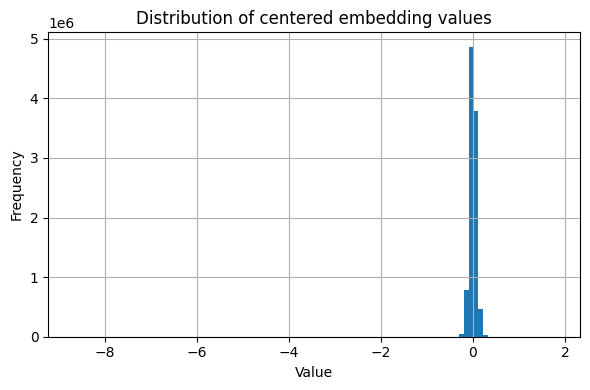

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# --- загрузка ---
data = np.load("embeddings/toxin_embeddings_large.npz", allow_pickle=True)

names = data["names"]
emb = data["embeddings"]

print("=== STRUCTURE ===")
print("names:", names.shape, names.dtype)
print("embeddings:", emb.shape, emb.dtype)

print("\n=== SAMPLE ===")
for i in range(min(5, len(names))):
    print(f"{i}: {names[i]} | emb[:5]={emb[i][:5]}")

print("\nmean/std:", emb.mean(), emb.std())

# --- гистограмма ---
plt.figure(figsize=(6,4))
plt.hist(emb.flatten(), bins=100)
plt.title("Distribution of centered embedding values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- PCA ---
X2 = PCA(n_components=2).fit_transform(emb)

plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1])

for i, name in enumerate(names):
    plt.annotate(name[:20], (X2[i,0], X2[i,1]), fontsize=8)

plt.title("PCA projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

Теперь посмотрим на сходства между разными токсинами (по фану, и чтобы проверить, что метода рабочая)

In [ ]:
#параметры, чтобы крутить!
TOP_THRESHOLD = 0.9
BOTTOM_THRESHOLD = -0.4
PRINT_ALL = False


# --- cosine similarity ---
sim = cosine_similarity(emb)

plt.figure(figsize=(7,6))
im = plt.imshow(sim)
plt.colorbar(im, label="Cosine similarity")

plt.xticks(range(len(names)), names, rotation=90)
plt.yticks(range(len(names)), names)

plt.title("Cosine similarity matrix")
plt.xlabel("Protein")
plt.ylabel("Protein")

plt.tight_layout()
plt.show()

#топ сходств
print("\n=== TOP SIMILARITY (sorted) ===")

pairs = []
for i in range(len(names)):
    for j in range(i+1, len(names)):
      if sim[i, j] > TOP_THRESHOLD:
        pairs.append((sim[i,j], names[i], names[j]))

pairs.sort(reverse=True)

for score, n1, n2 in pairs[:5]:
    print(f"{score:6.3f} | {n1}  <->  {n2}")

#анти-топ сходств
print("\n=== LOWEST SIMILARITY (sorted) ===")

pairs = []
for i in range(len(names)):
    for j in range(i+1, len(names)):
      if sim[i, j] < BOTTOM_THRESHOLD:
        pairs.append((sim[i,j], names[i], names[j]))

pairs.sort(reverse=False)

for score, n1, n2 in pairs[:5]:
    print(f"{score:6.3f} | {n1}  <->  {n2}")

# --- читаемый список пар ---
if PRINT_ALL == True:
  print("\n=== PAIRWISE SIMILARITY (sorted) ===")

  pairs = []
  for i in range(len(names)):
      for j in range(i+1, len(names)):
          pairs.append((sim[i,j], names[i], names[j]))

  pairs.sort(reverse=True)

  for score, n1, n2 in pairs:
      print(f"{score:6.3f} | {n1}  <->  {n2}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Загрузи обе базы
tox_data = np.load("embeddings/toxin_embeddings_large.npz", allow_pickle=True)
bg_data  = np.load("embeddings/neutral_embeddings_large.npz", allow_pickle=True)

tox_emb = tox_data["embeddings"]
bg_emb  = bg_data["embeddings"]

# Глобальное среднее по обоим
all_emb = np.concatenate([tox_emb, bg_emb], axis=0)
ref_mean = all_emb.mean(axis=0)

# Центрируем относительно ГЛОБАЛЬНОГО среднего
def center_norm(emb, mean):
    c = emb - mean
    norms = np.linalg.norm(c, axis=1, keepdims=True)
    return c / np.maximum(norms, 1e-8)

tox_c = center_norm(tox_emb, ref_mean)
bg_c  = center_norm(bg_emb,  ref_mean)

# Cross-similarity: токсин vs фон
cross_sim = tox_c @ bg_c.T  # shape (200, 200)
print("Toxin vs Background similarity:")
print(f"  mean:  {cross_sim.mean():.3f}")
print(f"  min:   {cross_sim.min():.3f}")
print(f"  max:   {cross_sim.max():.3f}")

# Внутри токсинов
tox_sim = tox_c @ tox_c.T
np.fill_diagonal(tox_sim, np.nan)
print(f"\nToxin vs Toxin (internal):")
print(f"  mean:  {np.nanmean(tox_sim):.3f}")

# Внутри фона
bg_sim = bg_c @ bg_c.T
np.fill_diagonal(bg_sim, np.nan)
print(f"\nBackground vs Background (internal):")
print(f"  mean:  {np.nanmean(bg_sim):.3f}")